## Tennis Versus (02 - restructuring the data and removing some unneeded features)

We have saved our work from ```01_data_exploration.ipynb``` into ```cleaned_matches_01done.parquet```.

We can now use our DataFrame from 01 here. We will now restructure the data so it will actually be useful with our model.

In [3]:
# data analytics + math
import pandas as pd 
import numpy as np 

# data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# other stuff used for later (need sci-kit learn too)
import xgboost # just installed it using !pip install

# set some parameters for pandas to view the data a bit better
pd.set_option('display.max_columns', 50) # see ALL columns
pd.set_option('display.width', 150)

df = pd.read_parquet('parquets/cleaned_matches_01done.parquet')

### renaming + deleting columns

there's a lot of columns in this DataFrame. Some seem more useful than others.

for example, ```tourney_id``` and player id are just identifiers - not useful for our model.
```winner_seed``` ```winner_entry``` is also not that important.

Most importantly, our dataset inherently labels the winner using the column names already. 
We want to separate this so our model doesn't take that into account.

What we want is more of a ```player_a``` and ```player_b``` and a ```label``` column signifying who won. 

In our case, ```label``` will basically be asking: "Did player A win?". ```1``` if player A wins, and ```0``` if player A loses (or player B wins).

#### important side note

ok, so we will rename ```winner_name``` --> ```player_a``` and ```loser_name``` --> ```player_b```. <br>
Then, ```label``` will be all ```1``` because we have constructed it so that player A is the winner.

Our model will simply always predict ```1``` because that's all there is.

Thus, we also need to add a "flipped" direction. In addition to what we did above, we will also add: <br>
```loser_name``` --> ```player_a``` and ```winner_name``` --> ```player_b```. Then ```label``` will be  ```0``` because player A didn't win.

Now, the model will actually have 0s and 1s to work with and figure out which features are most important and correlate the most.

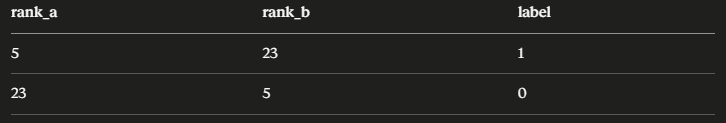

is much more useful than

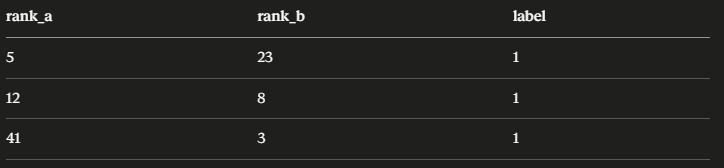

because there is now actually a way for our model to predict our label to be 0 or 1.

In [4]:
def restructure_matches(df):

    # Original direction: player_a = winner, label = 1
    df_a = pd.DataFrame({
        'tourney_date':  df['tourney_date'],
        'tourney_name':  df['tourney_name'],
        'tourney_level': df['tourney_level'],
        'surface':       df['surface'],
        'round':         df['round'],
        'best_of':       df['best_of'],
        'player_a':      df['winner_name'],
        'player_b':      df['loser_name'],
        'rank_a':        df['winner_rank'],
        'rank_b':        df['loser_rank'],
        'age_a':         df['winner_age'],
        'age_b':         df['loser_age'],
        'svpt_a':        df['w_svpt'],
        'svpt_b':        df['l_svpt'],
        'firstIn_a':     df['w_1stIn'],
        'firstIn_b':     df['l_1stIn'],
        'firstWon_a':    df['w_1stWon'],
        'firstWon_b':    df['l_1stWon'],
        'bpSaved_a':     df['w_bpSaved'],
        'bpSaved_b':     df['l_bpSaved'],
        'bpFaced_a':     df['w_bpFaced'],
        'bpFaced_b':     df['l_bpFaced'],
        'label':         1
    })

    # Flipped direction: player_a = loser, label = 0
    df_b = pd.DataFrame({
        'tourney_date':  df['tourney_date'],
        'tourney_name':  df['tourney_name'],
        'tourney_level': df['tourney_level'],
        'surface':       df['surface'],
        'round':         df['round'],
        'best_of':       df['best_of'],
        'player_a':      df['loser_name'],
        'player_b':      df['winner_name'],
        'rank_a':        df['loser_rank'],
        'rank_b':        df['winner_rank'],
        'age_a':         df['loser_age'],
        'age_b':         df['winner_age'],
        'svpt_a':        df['l_svpt'],
        'svpt_b':        df['w_svpt'],
        'firstIn_a':     df['l_1stIn'],
        'firstIn_b':     df['w_1stIn'],
        'firstWon_a':    df['l_1stWon'],
        'firstWon_b':    df['w_1stWon'],
        'bpSaved_a':     df['l_bpSaved'],
        'bpSaved_b':     df['w_bpSaved'],
        'bpFaced_a':     df['l_bpFaced'],
        'bpFaced_b':     df['w_bpFaced'],
        'label':         0
    })

    # merge
    result = pd.concat([df_a, df_b], ignore_index=True)

    # at this point, it will be all label 1s then all label 0s
    # here, we sort it back into chronological order
    result = result.sort_values('tourney_date').reset_index(drop=True)
    return result

data = restructure_matches(df)

print(data['label'].value_counts())

label
1    22393
0    22393
Name: count, dtype: int64


### adding useful features

it's time to add some useful statistics to help our model predict better.

#### Important (imo)
- difference in ranks
- H2H between the two players
- player's recent form overall (recently playing good or bad?)
  - recent form surface-wise too
- service hold rate + break rate


#### Can be added later
- more specific serve stats (1st serve, 2nd serve percentages)
- winrate for specific level of tourney (Grandslams, Masters, 500s...)

In [5]:
# difference in ranks
data['rank_diff'] = data['rank_a'] - data['rank_b'] # negative should be 1, positive should be 0

In [14]:
# recent tennis form (on a hot streak or not)
def find_recent_forms(data, last_N=10): # default - last 10 matches

    # NOTE: the label is 1 if player A wins, 0 if player A loses
    # thus, to look at all the games of a certain player, we need to find his name on the 'player_a' column
    
    form_a, form_b = [], [] # will be the columns at the end of the loop
    
    # find player A's most recent 10 matches
    for i, row in data.iterrows():
        # use bitwise & operator, can compare datetime using <,>,==, etc.
        past_a = data[(data['player_a'] == row['player_a']) & (data['tourney_date'] < row['tourney_date'])].tail(last_N)
        past_b = data[(data['player_a'] == row['player_b']) & (data['tourney_date'] < row['tourney_date'])].tail(last_N)

        if len(past_a) >= 3: # more than 3 matches
            form_a.append(past_a['label'].mean()) # .mean() is a nice way to calculate winning percentage
        else:
            form_a.append(0.5) # default - give equal winning chances to both players\\

        if len(past_b) >= 3: # only 2 matches
            form_b.append(past_b['label'].mean()) # .mean() is a nice way to calculate winning percentage
        else:
            form_b.append(0.5) # default - give equal winning chances to both players
            
    data['form_a'] = form_a
    data['form_b'] = form_b

# call the function to actually make the new features
find_recent_forms(data)

data.tail()


,tourney_date,tourney_name,tourney_level,surface,round,best_of,player_a,player_b,rank_a,rank_b,age_a,age_b,svpt_a,svpt_b,firstIn_a,firstIn_b,firstWon_a,firstWon_b,bpSaved_a,bpSaved_b,bpFaced_a,bpFaced_b,label,rank_diff,form_a,form_b
44781,2026-06-20,Halle,500,Grass,SF,3,Alexander Zverev,Taylor Fritz,3.0,9.0,29.166,28.643,95.0,98.0,59.0,67.0,49.0,57.0,3.0,1.0,6.0,2.0,0,-6.0,1.0,0.6
44782,2026-06-21,Queen's Club,500,Grass,F,3,Francisco Cerundolo,Tommy Paul,27.0,28.0,27.855,29.095,126.0,105.0,75.0,57.0,50.0,40.0,8.0,8.0,10.0,12.0,1,-1.0,0.7,0.8
44783,2026-06-21,Halle,500,Grass,F,3,Frances Tiafoe,Taylor Fritz,26.0,9.0,28.416,28.646,47.0,58.0,35.0,44.0,32.0,33.0,0.0,5.0,0.0,7.0,1,17.0,0.8,0.7
44784,2026-06-21,Halle,500,Grass,F,3,Taylor Fritz,Frances Tiafoe,9.0,26.0,28.646,28.416,58.0,47.0,44.0,35.0,33.0,32.0,5.0,0.0,7.0,0.0,0,-17.0,0.7,0.8
44785,2026-06-21,Queen's Club,500,Grass,F,3,Tommy Paul,Francisco Cerundolo,28.0,27.0,29.095,27.855,105.0,126.0,57.0,75.0,40.0,50.0,8.0,8.0,12.0,10.0,0,1.0,0.8,0.7


In [16]:
# the same as above but taking into account surface
def find_recent_forms_surface(data, last_N=10):
    form_a, form_b = [], [] # will be the columns at the end of the loop
    
    # find player A's most recent 10 matches
    for i, row in data.iterrows():
        # use bitwise & operator, can compare datetime using <,>,==, etc.
        matchingName = data['player_a'] == row['player_a']
        priorTourney = data['tourney_date'] < row['tourney_date']
        matchingSurface = data['surface'] == row['surface']
        
        past_a = data[matchingName & priorTourney & matchingSurface].tail(last_N)
        past_b = data[matchingName & priorTourney & matchingSurface].tail(last_N)

        if len(past_a) >= 3: # more than 3 matches
            form_a.append(past_a['label'].mean()) # .mean() is a nice way to calculate winning percentage
        else:
            form_a.append(0.5) # default - give equal winning chances to both players\\

        if len(past_b) >= 3: # only 2 matches
            form_b.append(past_b['label'].mean()) # .mean() is a nice way to calculate winning percentage
        else:
            form_b.append(0.5) # default - give equal winning chances to both players
            
    data['surface_form_a'] = form_a
    data['surface_form_b'] = form_b

# call the function to actually make the new features
find_recent_forms_surface(data)
data.tail()
    

,tourney_date,tourney_name,tourney_level,surface,round,best_of,player_a,player_b,rank_a,rank_b,age_a,age_b,svpt_a,svpt_b,firstIn_a,firstIn_b,firstWon_a,firstWon_b,bpSaved_a,bpSaved_b,bpFaced_a,bpFaced_b,label,rank_diff,form_a,form_b,surface_form_a,surface_form_b
44781,2026-06-20,Halle,500,Grass,SF,3,Alexander Zverev,Taylor Fritz,3.0,9.0,29.166,28.643,95.0,98.0,59.0,67.0,49.0,57.0,3.0,1.0,6.0,2.0,0,-6.0,1.0,0.6,0.8,0.8
44782,2026-06-21,Queen's Club,500,Grass,F,3,Francisco Cerundolo,Tommy Paul,27.0,28.0,27.855,29.095,126.0,105.0,75.0,57.0,50.0,40.0,8.0,8.0,10.0,12.0,1,-1.0,0.7,0.8,0.4,0.4
44783,2026-06-21,Halle,500,Grass,F,3,Frances Tiafoe,Taylor Fritz,26.0,9.0,28.416,28.646,47.0,58.0,35.0,44.0,32.0,33.0,0.0,5.0,0.0,7.0,1,17.0,0.8,0.7,0.7,0.7
44784,2026-06-21,Halle,500,Grass,F,3,Taylor Fritz,Frances Tiafoe,9.0,26.0,28.646,28.416,58.0,47.0,44.0,35.0,33.0,32.0,5.0,0.0,7.0,0.0,0,-17.0,0.7,0.8,0.9,0.9
44785,2026-06-21,Queen's Club,500,Grass,F,3,Tommy Paul,Francisco Cerundolo,28.0,27.0,29.095,27.855,105.0,126.0,57.0,75.0,40.0,50.0,8.0,8.0,12.0,10.0,0,1.0,0.8,0.7,0.8,0.8


In [18]:
# H2H
def h2h(data):
    res = []

    for _, row in data.iterrows():
        matchA = data['player_a'] == row['player_a']
        matchB = data['player_b'] == row['player_b']
        priorTourney = data['tourney_date'] < row['tourney_date']
        
        past = data[matchA & matchB & priorTourney]
        
        res.append(past['label'].mean() if len(past) >= 2 else 0.5)


    data['h2h_winrate_a'] = res

h2h(data)

data.tail()

,tourney_date,tourney_name,tourney_level,surface,round,best_of,player_a,player_b,rank_a,rank_b,age_a,age_b,svpt_a,svpt_b,firstIn_a,firstIn_b,firstWon_a,firstWon_b,bpSaved_a,bpSaved_b,bpFaced_a,bpFaced_b,label,rank_diff,form_a,form_b,surface_form_a,surface_form_b,h2h_winrate_a
44781,2026-06-20,Halle,500,Grass,SF,3,Alexander Zverev,Taylor Fritz,3.0,9.0,29.166,28.643,95.0,98.0,59.0,67.0,49.0,57.0,3.0,1.0,6.0,2.0,0,-6.0,1.0,0.6,0.8,0.8,0.307692
44782,2026-06-21,Queen's Club,500,Grass,F,3,Francisco Cerundolo,Tommy Paul,27.0,28.0,27.855,29.095,126.0,105.0,75.0,57.0,50.0,40.0,8.0,8.0,10.0,12.0,1,-1.0,0.7,0.8,0.4,0.4,0.714286
44783,2026-06-21,Halle,500,Grass,F,3,Frances Tiafoe,Taylor Fritz,26.0,9.0,28.416,28.646,47.0,58.0,35.0,44.0,32.0,33.0,0.0,5.0,0.0,7.0,1,17.0,0.8,0.7,0.7,0.7,0.000000
44784,2026-06-21,Halle,500,Grass,F,3,Taylor Fritz,Frances Tiafoe,9.0,26.0,28.646,28.416,58.0,47.0,44.0,35.0,33.0,32.0,5.0,0.0,7.0,0.0,0,-17.0,0.7,0.8,0.9,0.9,1.000000
44785,2026-06-21,Queen's Club,500,Grass,F,3,Tommy Paul,Francisco Cerundolo,28.0,27.0,29.095,27.855,105.0,126.0,57.0,75.0,40.0,50.0,8.0,8.0,12.0,10.0,0,1.0,0.8,0.7,0.8,0.8,0.285714


In [20]:
# finding holding + breaking rate
def hold_rate(data):
    pass

print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44786 entries, 0 to 44785
Data columns (total 29 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   tourney_date    44786 non-null  datetime64[ns]
 1   tourney_name    44786 non-null  object        
 2   tourney_level   44786 non-null  object        
 3   surface         44786 non-null  object        
 4   round           44784 non-null  object        
 5   best_of         44786 non-null  int64         
 6   player_a        44786 non-null  object        
 7   player_b        44786 non-null  object        
 8   rank_a          44786 non-null  float64       
 9   rank_b          44786 non-null  float64       
 10  age_a           44769 non-null  float64       
 11  age_b           44769 non-null  float64       
 12  svpt_a          44786 non-null  float64       
 13  svpt_b          44786 non-null  float64       
 14  firstIn_a       44786 non-null  float64       
 15  fi

In [21]:
# actually, finding an average on how many BPs a player faces per match might be important
def bp_pressure(data, last_N=10):

    pressure_a = []
    pressure_b = []
    
    for _, row in data.iterrows():
    
        past_a = data[
            (data['player_a'] == row['player_a']) &
            (data['tourney_date'] < row['tourney_date'])
        ].tail(last_N)

        past_b = data[
            (data['player_a'] == row['player_b']) &
            (data['tourney_date'] < row['tourney_date'])
        ].tail(last_N)

        # let's say default is 5
        pressure_a.append((past_a['bpFaced_a'].sum() / len(past_a)) if len(past_a) >= 3 else 5)
        pressure_b.append((past_b['bpFaced_a'].sum() / len(past_b)) if len(past_b) >= 3 else 5)

    data['bp_pressure_a'] = pressure_a
    data['bp_pressure_b'] = pressure_b

bp_pressure(data)
data.tail()

        
    

,tourney_date,tourney_name,tourney_level,surface,round,best_of,player_a,player_b,rank_a,rank_b,age_a,age_b,svpt_a,svpt_b,firstIn_a,firstIn_b,firstWon_a,firstWon_b,bpSaved_a,bpSaved_b,bpFaced_a,bpFaced_b,label,rank_diff,form_a,form_b,surface_form_a,surface_form_b,h2h_winrate_a,bp_pressure_a,bp_pressure_b
44781,2026-06-20,Halle,500,Grass,SF,3,Alexander Zverev,Taylor Fritz,3.0,9.0,29.166,28.643,95.0,98.0,59.0,67.0,49.0,57.0,3.0,1.0,6.0,2.0,0,-6.0,1.0,0.6,0.8,0.8,0.307692,3.1,5.0
44782,2026-06-21,Queen's Club,500,Grass,F,3,Francisco Cerundolo,Tommy Paul,27.0,28.0,27.855,29.095,126.0,105.0,75.0,57.0,50.0,40.0,8.0,8.0,10.0,12.0,1,-1.0,0.7,0.8,0.4,0.4,0.714286,7.9,5.8
44783,2026-06-21,Halle,500,Grass,F,3,Frances Tiafoe,Taylor Fritz,26.0,9.0,28.416,28.646,47.0,58.0,35.0,44.0,32.0,33.0,0.0,5.0,0.0,7.0,1,17.0,0.8,0.7,0.7,0.7,0.000000,6.2,4.2
44784,2026-06-21,Halle,500,Grass,F,3,Taylor Fritz,Frances Tiafoe,9.0,26.0,28.646,28.416,58.0,47.0,44.0,35.0,33.0,32.0,5.0,0.0,7.0,0.0,0,-17.0,0.7,0.8,0.9,0.9,1.000000,4.2,6.2
44785,2026-06-21,Queen's Club,500,Grass,F,3,Tommy Paul,Francisco Cerundolo,28.0,27.0,29.095,27.855,105.0,126.0,57.0,75.0,40.0,50.0,8.0,8.0,12.0,10.0,0,1.0,0.8,0.7,0.8,0.8,0.285714,5.8,7.9


In [ ]:
### finalizing dataset

ok, now we 

### we are done (for now)

We have restructured our dataset - now it should be ready for us to actually do something with it.

Once again, we save it to a parquet file into ```parquets/``` directory.


In [22]:
data.to_parquet('restructured_matches_02done.parquet')